This notebook was started using the Advanced RAG cookbook from Huggingface. https://huggingface.co/learn/cookbook/advanced_rag

As we specialize our model for our research we will diverge from this proof of concept system

In [16]:
!pip install -q torch langchain-text-splitters langchain-huggingface transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl pacmap datasets langchain-community ragatouille jedi

ERROR: Operation cancelled by user


In [ ]:
from tqdm.notebook import tqdm
import pandas as pd
from typing import Optional, List, Tuple
import datasets
import matplotlib.pyplot as plt


In [ ]:
DATASET_NAME = "m-ric/huggingface_doc"
TOKENIZER_NAME = "thenlper/gte-small"

In [ ]:

ds = datasets.load_dataset(DATASET_NAME, split="train")
df = ds.to_pandas()
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,text,source
0,"Create an Endpoint\n\nAfter your first login,...",huggingface/hf-endpoints-documentation/blob/ma...
1,Choosing a metric for your task\n\n**So you'v...,huggingface/evaluate/blob/main/docs/source/cho...
2,主要特点\n\n让我们来介绍一下 Gradio 最受欢迎的一些功能！这里是 Gradio ...,gradio-app/gradio/blob/main/guides/cn/01_getti...
3,!--Copyright 2023 The HuggingFace Team. All ri...,huggingface/transformers/blob/main/docs/source...
4,Gradio Demo: blocks_random_slider\n\n\n```\n!...,gradio-app/gradio/blob/main/demo/blocks_random...


In [ ]:
from langchain_core.documents import Document as LangchainDocument

RAW_KNOWLEDGE_BASE = [
    LangchainDocument(page_content=doc["text"], metadata={"source": doc["source"]})
    for doc in tqdm(ds)
]
print(RAW_KNOWLEDGE_BASE[0])

  0%|          | 0/2647 [00:00<?, ?it/s]

page_content=' Create an Endpoint

After your first login, you will be directed to the [Endpoint creation page](https://ui.endpoints.huggingface.co/new). As an example, this guide will go through the steps to deploy [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) for text classification. 

## 1. Enter the Hugging Face Repository ID and your desired endpoint name:

<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_repository.png" alt="select repository" />

## 2. Select your Cloud Provider and region. Initially, only AWS will be available as a Cloud Provider with the `us-east-1` and `eu-west-1` regions. We will add Azure soon, and if you need to test Endpoints with other Cloud Providers or regions, please let us know.

<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_region.png" alt="select region" />

## 3. Define the [

In [ ]:
# Defines prefered splitting behavior for documents
MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    " ",
    "",
]

Docs done


  0%|          | 0/16776 [00:00<?, ?it/s]

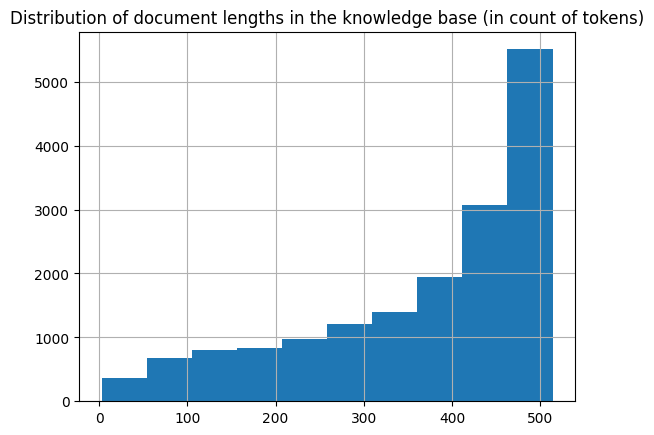

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer


def split_documents(
    chunk_size: int,
    knowledge_base: List[LangchainDocument],
    tokenizer_name: Optional[str] = TOKENIZER_NAME,
) -> List[LangchainDocument]:
    """
    Split documents into chunks of maximum size `chunk_size` tokens and return a list of documents.
    """
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        AutoTokenizer.from_pretrained(tokenizer_name),
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        add_start_index=True,
        strip_whitespace=True,
        separators=MARKDOWN_SEPARATORS,
    )

    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])

    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)

    return docs_processed_unique


docs_processed = split_documents(
    512,
    RAW_KNOWLEDGE_BASE,
    tokenizer_name=TOKENIZER_NAME
)
print("Docs done")

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]
fig = pd.Series(lengths).hist()
plt.title("Distribution of document lengths in the knowledge base (in count of tokens)")
plt.show()

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain_community.vectorstores import FAISS

embedding_model = HuggingFaceEmbeddings(
    model_name=TOKENIZER_NAME,
    multi_process=True,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:

user_query = "How to create a pipeline object?"
query_vector = embedding_model.embed_query(user_query)

In [ ]:
import pacmap
import numpy as np
import plotly.express as px

embedding_projector = pacmap.PaCMAP(
    n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0, random_state=1
)

embeddings_2d = [
    list(KNOWLEDGE_VECTOR_DATABASE.index.reconstruct_n(idx, 1)[0])
    for idx in range(len(docs_processed))
] + [query_vector]

# Fit the data (the index of transformed data corresponds to the index of the original data)
documents_projected = embedding_projector.fit_transform(
    np.array(embeddings_2d), init="pca"
)

In [ ]:
df = pd.DataFrame.from_dict(
    [
        {
            "x": documents_projected[i, 0],
            "y": documents_projected[i, 1],
            "source": docs_processed[i].metadata["source"].split("/")[1],
            "extract": docs_processed[i].page_content[:100] + "...",
            "symbol": "circle",
            "size_col": 4,
        }
        for i in range(len(docs_processed))
    ]
    + [
        {
            "x": documents_projected[-1, 0],
            "y": documents_projected[-1, 1],
            "source": "User query",
            "extract": user_query,
            "size_col": 100,
            "symbol": "star",
        }
    ]
)

# Visualize the embedding
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="source",
    hover_data="extract",
    size="size_col",
    symbol="symbol",
    color_discrete_map={"User query": "black"},
    width=1000,
    height=700,
)
fig.update_traces(
    marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)
fig.update_layout(
    legend_title_text="<b>Chunk source</b>",
    title="<b>2D Projection of Chunk Embeddings via PaCMAP</b>",
)
fig.show()

In [ ]:
print("***** RETRIEVAL *****")

retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=5)

print("***** RESULTS *****")
for idx, doc in enumerate(retrieved_docs):
    print("\n**** SOURCE ****")
    print(f"Source: {doc.metadata['source']}")
    print("\n**** CONTENT ****")
    print(f"Extract: {doc.page_content[:100]}...")

***** RETRIEVAL *****
***** RESULTS *****

**** SOURCE ****
Source: huggingface/transformers/blob/main/docs/source/en/quicktour.md

**** CONTENT ****
Extract: ```
</tf>
</frameworkcontent>

## Pipeline

<Youtube id="tiZFewofSLM"/>

The [`pipeline`] is the eas...

**** SOURCE ****
Source: huggingface/diffusers/blob/main/docs/source/en/using-diffusers/conditional_image_generation.md

**** CONTENT ****
Extract: ```

2. Pass a prompt to the pipeline to generate an image:

```py
image = pipeline(
	"stained glass...

**** SOURCE ****
Source: huggingface/diffusers/blob/main/docs/source/en/conceptual/philosophy.md

**** CONTENT ****
Extract: - Pipelines should be very readable, self-explanatory, and easy to tweak.
- Pipelines should be desi...

**** SOURCE ****
Source: huggingface/transformers/blob/main/docs/source/en/add_new_pipeline.md

**** CONTENT ****
Extract: !--Copyright 2020 The HuggingFace Team. All rights reserved.

Licensed under the Apache License, Ver...

**** SOURCE ****
Source: 

In [ ]:
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

READER_MODEL_NAME = "HuggingFaceH4/zephyr-7b-beta"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model = AutoModelForCausalLM.from_pretrained(
    READER_MODEL_NAME, quantization_config=bnb_config
)
tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)

READER_LLM = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    do_sample=True,
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=500,
)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'repetition_penalty', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
#test reader
READER_LLM("Whats the Capitol of Canada?")

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': '\n\nThe capital city of Canada is Ottawa. It is located in the province of Ontario, on the south bank of the Ottawa River. The city became the capital when Canada was formed in 1867, and it has served as the political center of the country ever since. Some notable landmarks in Ottawa include Parliament Hill, Rideau Hall (the official residence of the Governor General), and the National Gallery of Canada.'}]

In [15]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.""",
    },
    {
        "role": "user",
        "content": """Context:
{context}
---
Now here is the question you need to answer.

Question: {question}""",
    },
]
RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)
print(RAG_PROMPT_TEMPLATE)

<|system|>
Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.</s>
<|user|>
Context:
{context}
---
Now here is the question you need to answer.

Question: {question}</s>
<|assistant|>



In [17]:
retrieved_docs_text = [
    doc.page_content for doc in retrieved_docs
]  # We only need the text of the documents
context = "\nExtracted documents:\n"
context += "".join(
    [f"Document {str(i)}:::\n" + doc for i, doc in enumerate(retrieved_docs_text)]
)

final_prompt = RAG_PROMPT_TEMPLATE.format(
    question="How to create a pipeline object?", context=context
)

# Redact an answer
answer = READER_LLM(final_prompt)[0]["generated_text"]
print(answer)

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


To create a pipeline object, follow these steps:

1. Define the inputs and outputs of your pipeline. This could be strings, raw bytes, dictionaries, or any other desired input format.

2. Create a new class that inherits from the `Pipeline` class provided by the `transformers` library.

3. Implement the four required methods: `_sanitize_parameters`, `preprocess`, `_forward`, and `postprocess`.

   - `_sanitize_parameters` takes in keyword arguments and returns a tuple containing two dictionaries: `preprocess_args` and `forward_args`. This method is used to sanitize and convert the input arguments into the correct format for the pipeline.

   - `preprocess` takes in the inputs and any additional arguments and returns a dictionary containing the processed inputs. This method is responsible for preparing the inputs for the forward pass.

   - `_forward` takes in the processed inputs and returns the output of the forward pass. This method is implemented in the child class and should call t